In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\91790\OneDrive\Desktop\DA and ML\Project\LR_Polinomial\FuelConsumptionCo2.csv")

In [4]:
df.isnull().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

In [38]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())


['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS', 'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']


In [11]:
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']].values
y = df['CO2EMISSIONS'].values

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['ENGINESIZE']].values
y = df['CO2EMISSIONS'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # use same transformer

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model.predict(X_test_poly)
print(y_pred)

[310.94349053 265.11798359 269.06075175 245.06602661 203.27153193
 245.06602661 269.06075175 284.60641365 321.89269305 269.06075175
 269.06075175 380.10619098 253.15443263 265.11798359 269.06075175
 265.11798359 185.92258392 269.06075175 185.92258392 332.63902588
 321.89269305 194.64214008 253.15443263 272.98097884 245.06602661
 194.64214008 203.27153193 185.92258392 339.69054238 253.15443263
 336.17605467 220.25982272 194.64214008 321.89269305 245.06602661
 310.94349053 284.60641365 332.63902588 203.27153193 224.45054273
 185.92258392 185.92258392 177.11286345 224.45054273 284.60641365
 185.92258392 245.06602661 245.06602661 203.27153193 329.07945601
 363.66080623 269.06075175 203.27153193 272.98097884 245.06602661
 332.63902588 332.63902588 346.65189458 203.27153193 296.02897877
 284.60641365 296.02897877 299.79141833 269.06075175 185.92258392
 261.15267435 177.11286345 314.61576578 245.06602661 272.98097884
 321.89269305 203.27153193 265.11798359 203.27153193 203.27153193
 269.06075

In [30]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 960.8705832028329
RMSE: 30.997912562023156
R2: 0.7676219471812655


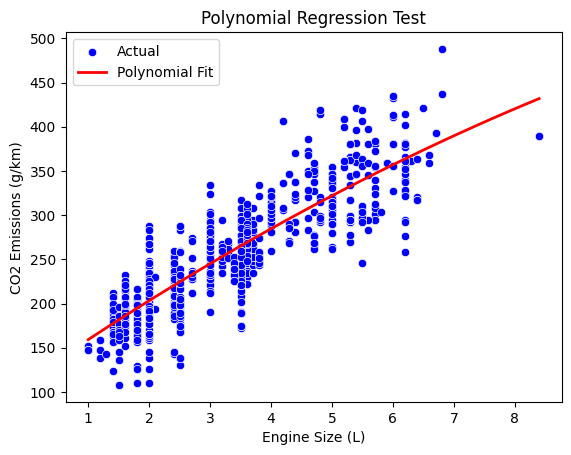

In [31]:
sns.scatterplot(x=X.flatten(), y=y, color='blue', label='Actual')

# Polynomial curve for visualization
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_curve = model.predict(poly.transform(X_curve))

plt.plot(X_curve, y_curve, color='red', linewidth=2, label='Polynomial Fit')
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Polynomial Regression Test")
plt.legend()
plt.show()